In [1]:
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

# Deep Learning
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# MobileNetV3
from tensorflow.keras.applications import MobileNetV3Large

# Set the Image Size for MobileNetV3Large model
# Set BatchSize, EPOCHS, SEED, DATASET_DIR 

In [4]:

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 20
SEED = 42

DATASET_DIR = r"D:\AI\8. Deep Learning\Gender Prediction\gender_dataset"

# Split the Training and Testing Dataset

In [5]:
train_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 1668 files belonging to 2 classes.
Using 1335 files for training.


In [6]:

test_dataset = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="binary"
)

Found 1668 files belonging to 2 classes.
Using 333 files for validation.


# Findout How many Classes are present for dataset

In [7]:
class_names = train_dataset.class_names

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Class names: ['men', 'women']
Number of classes: 2


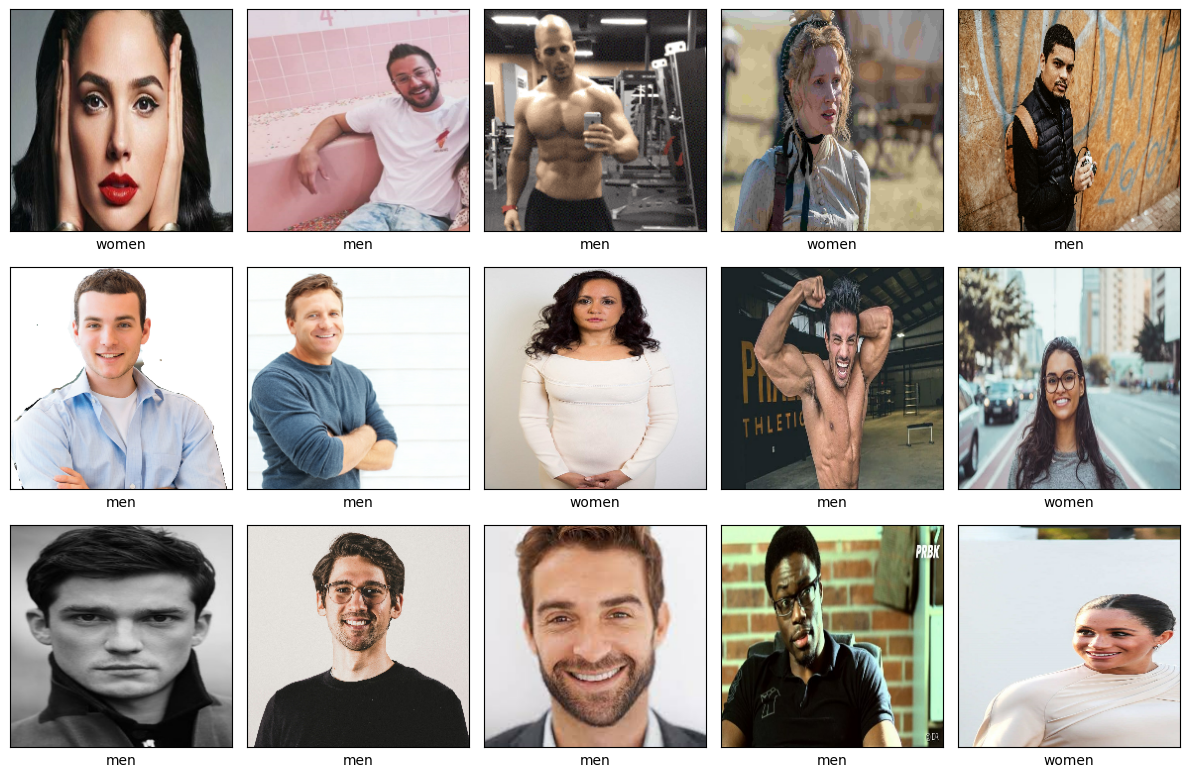

In [8]:
plt.figure(figsize=(12, 8))

for images, labels in train_dataset.take(1):
    for i in range(15):
        plt.subplot(3, 5, i + 1)
        plt.imshow( images[i].numpy().astype("uint8"))
        plt.xticks([])
        plt.yticks([])
        label = int(labels[i].numpy()[0])
        plt.xlabel(class_names[label])

plt.tight_layout()
plt.show()

# AUTOTUNE  - allows TensorFlow to automatically tune the prefetch buffer for better performance.
# prefetch - prepare the next data while the model is busy with the current data.

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.prefetch( buffer_size=AUTOTUNE)
test_dataset = test_dataset.prefetch( buffer_size=AUTOTUNE )

# Sequential -  the layers are applied one after another.
# RandomFlip -  randomly flips the image left ↔ right.
# RandomRotation - Randomly rotates the image slightly.
# RandomZoom -  Randomly zooms the image in or out.
# RandomContrast - Randomly changes the image's contrast.

In [10]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1)
])

# MobileNetV3Large - pre-trained CNN designed for accurate and efficient image recognition
# input_shape - (224, 224, 3) - Height = 224 pixels, Width  = 224 pixels, Channels = 3. Channels - R = Red, G = Green, B = Blue
# include_top=False -  remove the original classification layer so you can add your own classifier.
# weights="imagenet" - use pre-trained ImageNet weights, so the model can reuse already-learned visual features.
# pooling="avg" - apply Global Average Pooling to convert the feature maps into a compact 960-value feature vector.

In [11]:
base_model = tf.keras.applications.MobileNetV3Large(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet",
    pooling="avg"
)

# Freeze pretrained layers
base_model.trainable = False

In [12]:
inputs = keras.Input(shape=(224, 224, 3))

# Data augmentation
x = data_augmentation(inputs)

# Pretrained MobileNetV3
x = base_model(x, training=False)

# Classification layers
x = layers.Dropout(0.4)(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.3)(x)
# Binary classification
outputs = layers.Dense( 1, activation="sigmoid")(x)

model = keras.Model( inputs,outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ sequential (Sequential)              │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ MobileNetV3Large (Functional)        │ (None, 960)                 │       2,996,352 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 960)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │         123,008 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │             129 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,120,001 (11.90 MB)

 Trainable params: 123,393 (482.00 KB)

 Non-trainable params: 2,996,608 (11.43 MB)

In [13]:
model.compile( optimizer=keras.optimizers.Adam( learning_rate=0.0001),  loss="binary_crossentropy", metrics=["accuracy"])

In [14]:
history = model.fit( train_dataset,  epochs=EPOCHS,  validation_data=test_dataset)

Epoch 1/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 31s 527ms/step - accuracy: 0.5273 - loss: 0.9173 - val_accuracy: 0.5916 - val_loss: 0.7295
Epoch 2/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 478ms/step - accuracy: 0.6599 - loss: 0.6764 - val_accuracy: 0.8138 - val_loss: 0.4567
Epoch 3/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 21s 474ms/step - accuracy: 0.7408 - loss: 0.5187 - val_accuracy: 0.8619 - val_loss: 0.3282
Epoch 4/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 27s 646ms/step - accuracy: 0.7985 - loss: 0.4354 - val_accuracy: 0.9159 - val_loss: 0.2615
Epoch 5/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 52s 883ms/step - accuracy: 0.8277 - loss: 0.4017 - val_accuracy: 0.9219 - val_loss: 0.2260
Epoch 6/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 827ms/step - accuracy: 0.8375 - loss: 0.3650 - val_accuracy: 0.9279 - val_loss: 0.2008
Epoch 7/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 37s 827ms/step - accuracy: 0.8404 - loss: 0.3573 - val_accuracy: 0.9369 - val_loss: 0.1852
Epoch 8/20
42/42 ━━━━━━━━━━━━━━━━━━━━ 38s 864ms/step - accuracy: 0.8457 - loss: 0.3610 - val_accu

In [15]:
# Save trained MobileNetV3 model
model.save(
    r"D:\AI\8. Deep Learning\Gender Prediction\mobilenetv3_model.keras"
)

print("Model saved successfully!")

Model saved successfully!


In [16]:
test_loss, test_accuracy = model.evaluate(  test_dataset )
print( "MobileNetV3 Test Accuracy:", round(test_accuracy, 4))
print("MobileNetV3 Test Loss:", round(test_loss, 4))

11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 450ms/step - accuracy: 0.9489 - loss: 0.1403
MobileNetV3 Test Accuracy: 0.9489
MobileNetV3 Test Loss: 0.1403


In [17]:
y_true = []
y_pred_probability = []

for images, labels in test_dataset:
    predictions = model.predict( images,  verbose=0)
    y_true.extend( labels.numpy().flatten())
    y_pred_probability.extend(predictions.flatten())

y_true = np.array(y_true)
y_pred_probability = np.array(  y_pred_probability)

# Convert probability to class
y_pred = ( y_pred_probability >= 0.5).astype(int)

In [18]:
accuracy = accuracy_score( y_true, y_pred)
print("Test Accuracy:", round(accuracy, 4))

Test Accuracy: 0.9489


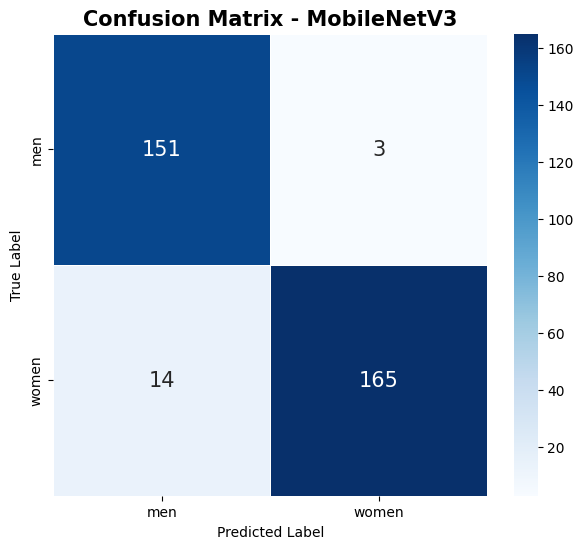

In [19]:
con_mat = confusion_matrix(  y_true,  y_pred )
plt.figure(figsize=(7, 6))
sns.heatmap(
    con_mat,
    annot=True,
    annot_kws={"size": 15},
    linewidths=0.5,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title(
    "Confusion Matrix - MobileNetV3",
    fontweight="bold",
    fontsize=15
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

In [20]:
print( classification_report( y_true,  y_pred,  target_names=class_names))

              precision    recall  f1-score   support

         men       0.92      0.98      0.95       154
       women       0.98      0.92      0.95       179

    accuracy                           0.95       333
   macro avg       0.95      0.95      0.95       333
weighted avg       0.95      0.95      0.95       333



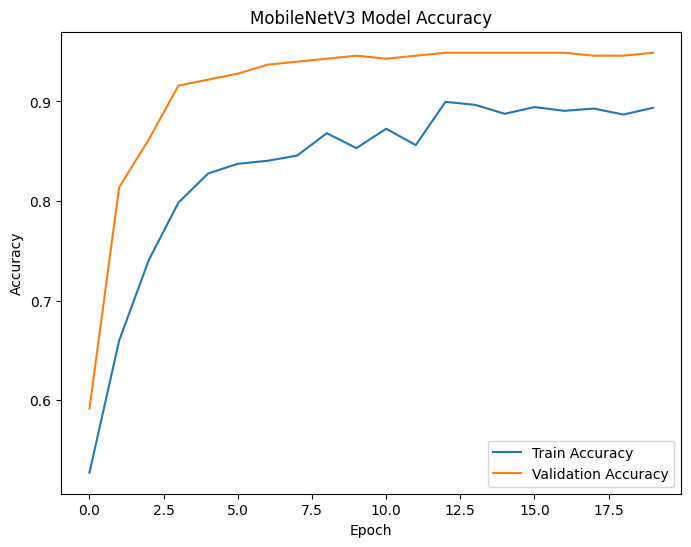

In [21]:
plt.figure(figsize=(8, 6))

plt.plot(
    history.history["accuracy"],
    label="Train Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.title(
    "MobileNetV3 Model Accuracy"
)

plt.ylabel("Accuracy")
plt.xlabel("Epoch")

plt.legend(
    loc="best"
)

plt.show()

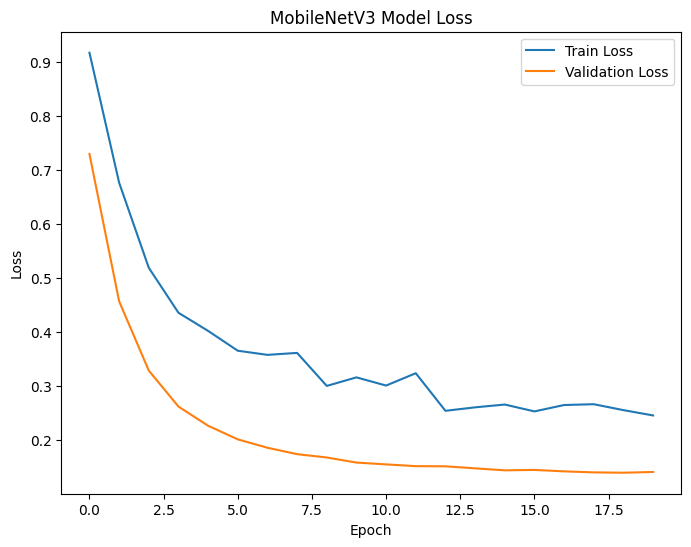

In [22]:

plt.figure(figsize=(8, 6))

plt.plot(
    history.history["loss"],
    label="Train Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title(
    "MobileNetV3 Model Loss"
)

plt.ylabel("Loss")
plt.xlabel("Epoch")

plt.legend(
    loc="best"
)

plt.show()

In [23]:
sample_image = r"D:\AI\8. Deep Learning\Gender Prediction\gender_dataset\22.jpeg"

img = tf.keras.utils.load_img(
    sample_image,
    target_size=IMG_SIZE
)

img_array = tf.keras.utils.img_to_array(
    img
)

img_array = tf.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(
    img_array,
    verbose=0
)

probability = float(
    prediction[0][0]
)

predicted_class = (
    1 if probability >= 0.5 else 0
)

print(
    "Predicted:",
    class_names[predicted_class]
)

print(
    "Probability:",
    round(probability, 4)
)

Predicted: women
Probability: 0.9403


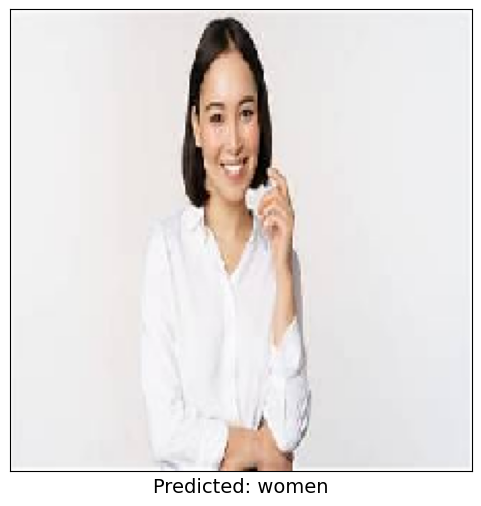

In [24]:
plt.figure(figsize=(6, 6))

plt.imshow(img)

plt.xticks([])
plt.yticks([])

plt.xlabel(
    "Predicted: {}".format(
        class_names[predicted_class]
    ),
    fontsize=14
)

plt.show()

In [25]:
# ============================================================
# 22. FINE-TUNING
# ============================================================

base_model.trainable = True

# Freeze earlier layers
for layer in base_model.layers[:-30]:
    layer.trainable = False


# Recompile with a very small learning rate
model.compile(
    optimizer=keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# Fine-tune
fine_tune_history = model.fit(
    train_dataset,
    epochs=10,
    validation_data=test_dataset
)

Epoch 1/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 75s 1s/step - accuracy: 0.8599 - loss: 0.3186 - val_accuracy: 0.9610 - val_loss: 0.1304
Epoch 2/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 41s 920ms/step - accuracy: 0.8479 - loss: 0.3473 - val_accuracy: 0.9520 - val_loss: 0.1293
Epoch 3/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8584 - loss: 0.3403 - val_accuracy: 0.9489 - val_loss: 0.1299
Epoch 4/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 45s 1s/step - accuracy: 0.8779 - loss: 0.3088 - val_accuracy: 0.9459 - val_loss: 0.1279
Epoch 5/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 50s 1s/step - accuracy: 0.8772 - loss: 0.2848 - val_accuracy: 0.9520 - val_loss: 0.1259
Epoch 6/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8809 - loss: 0.2949 - val_accuracy: 0.9489 - val_loss: 0.1239
Epoch 7/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.8839 - loss: 0.2842 - val_accuracy: 0.9489 - val_loss: 0.1221
Epoch 8/10
42/42 ━━━━━━━━━━━━━━━━━━━━ 40s 913ms/step - accuracy: 0.8861 - loss: 0.2593 - val_accuracy: 0.9520 - val

In [26]:
test_loss, test_accuracy = model.evaluate(  test_dataset )
print( "MobileNetV3 Test Accuracy:", round(test_accuracy, 4))
print("MobileNetV3 Test Loss:", round(test_loss, 4))

11/11 ━━━━━━━━━━━━━━━━━━━━ 7s 454ms/step - accuracy: 0.9580 - loss: 0.1171
MobileNetV3 Test Accuracy: 0.958
MobileNetV3 Test Loss: 0.1171


In [27]:
# Save trained MobileNetV3 model
model.save(
    r"D:\AI\8. Deep Learning\Gender Prediction\mobilenetv3_model.keras"
)

print("Model saved successfully!")

Model saved successfully!
